# L4 BMD & Microarchitecture — *Practical Pipeline v6 (YOLO26-seg)*

### *"The measurement of spinal bone architecture following hip surgery using X-ray datasets"*

A **practical, measurement-focused** pipeline. The L4 vertebra is segmented with a
**YOLO26-seg** instance model (instance detection naturally resolves *which* vertebra is L4 and
recovers it via a top→bottom fallback), and the measurement science is layered on top:

- **Bone Mineral Density (BMD)** — area-based density index from the *linear* (uncorrected)
  normalized intensity inside the predicted L4 ROI.
- **Bone Microarchitecture** — GLCM texture descriptors (Contrast, Correlation, Energy/ASM,
  Homogeneity) of the L4 trabecular region.
- **Evaluation** against the DICOM test ground-truth L4 masks (Dice / IoU / Precision / Recall,
  confusion matrix, Bland–Altman BMD agreement).
- **Web export** — the trained model is exported to **ONNX** for use in the web project.
- **XAI** — a gradient-based **Seg-Grad-CAM** on the L4 instance plus a **BMD-contribution heatmap**.

> ⚠️ **Clinical caveat.** Planar-radiograph "density" is an *uncorrected radiological proxy*
> (pixel intensity), **not** true areal BMD (g/cm²). Absolute BMD needs DXA/QCT or an in-image
> calibration phantom. Values below are relative indices for methodological demonstration.

---

### What changed in **v6**
1. **Backbone upgraded to `yolo26m-seg.pt`** (medium YOLO26 instance-segmentation). The previous
   `yolov8s-seg` is replaced. *Note:* this is the `-seg` variant — plain `yolo26m.pt` is a
   detection-only model and carries no masks, which this pipeline requires. Fallbacks if your GPU
   runs out of memory: `yolo26s-seg.pt` → `yolo26n-seg.pt`.
2. **New ONNX export step (Step 7)** — `best.pt` → `best.onnx` for the web project, with an ONNX-vs-
   PyTorch parity visualization. (The web-correct `simplify=True, opset=12` is used; `optimize=True`
   from the sample is TorchScript-only and not valid for ONNX.)
3. **Cleaner code** — duplicated YOLO helpers merged into one, the dead appendix snippet removed.
4. **Every cell visualizes its result** and **saves the figure** into an organized `l4_v6_output/`
   tree (`figures/`, `segmentation/`, `metrics/`, `export/`).


## 1. Clinical Definitions & Mathematical Formulation

### 1.1 Bone Mineral Density (BMD) — area-based intensity proxy
With the X-ray linearly normalized to $[0,1]$ and $\Omega_{L4}$ the predicted L4 ROI:
$$\text{BMD}_{\text{index}}=\frac{1}{|\Omega_{L4}|}\sum_{(x,y)\in\Omega_{L4}} I_{\text{norm}}(x,y),
\qquad I_{\text{norm}}=\frac{I-I_{\min}}{I_{\max}-I_{\min}}.$$
We use the **linear** (CLAHE-free) intensity for BMD so the density meaning is preserved, and report
median / std / p10 / p90 for distribution robustness.

### 1.2 Microarchitecture — Gray-Level Co-occurrence Matrix (GLCM)
Quantising the ROI to $L=32$ levels and averaging $P_\delta$ over
$\theta\in\{0,45,90,135^\circ\}$ at $d=1$:
$$\textbf{Contrast}=\sum_{i,j}(i-j)^2P(i,j),\quad \textbf{Energy/ASM}=\sum_{i,j}P(i,j)^2,$$
$$\textbf{Correlation}=\sum_{i,j}\frac{(i-\mu_i)(j-\mu_j)P(i,j)}{\sigma_i\sigma_j},\quad
\textbf{Homogeneity}=\sum_{i,j}\frac{P(i,j)}{1+|i-j|}.$$
Dense trabecular bone ⇒ high Energy/Homogeneity, low Contrast; disrupted/osteoporotic bone ⇒ higher
Contrast, lower Correlation.

## 0. Environment & Imports

Target: **Windows + RTX 5060 Laptop (CUDA)**. Requires `ultralytics` (YOLO26) and, for Step 7,
`onnxruntime`. Uncomment to install.

In [1]:
# !pip install ultralytics onnxruntime pydicom pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg \
# !             opencv-python-headless scikit-image scikit-learn matplotlib seaborn pandas

import os, glob, re, random, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from skimage.feature import graycomatrix, graycoprops
from ultralytics import YOLO

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
random.seed(42); np.random.seed(42)
print("OpenCV:", cv2.__version__)

OpenCV: 4.13.0


## 2. Configuration & Paths

All outputs land in a single organized tree (`OUT_DIR`), and a small `savefig()` helper writes every
figure into `figures/` so each cell leaves a saved artifact behind.

In [2]:
# -------------------- Data paths --------------------
BUU_ROOT      = "./BUU-LSPINE-2000/AP"
IMG_DIR       = os.path.join(BUU_ROOT, "images")
LBL_DIR       = os.path.join(BUU_ROOT, "labels")
TEST_DCM_DIR  = "./dataset-dcm/test/gather"
TEST_MASK_DIR = "./dataset-dcm/test/gather_mask/SegmentationClass"   # L4 ground-truth (PNG)

# -------------------- Output tree --------------------
OUT_DIR     = "./l4_v6_output"
FIG_DIR     = os.path.join(OUT_DIR, "figures")        # every cell's visualization
SEG_DIR     = os.path.join(OUT_DIR, "segmentation")   # per-image overlays + masks
METRICS_DIR = os.path.join(OUT_DIR, "metrics")        # CSVs
EXPORT_DIR  = os.path.join(OUT_DIR, "export")         # ONNX model for the web project
for _d in (OUT_DIR, FIG_DIR, SEG_DIR, METRICS_DIR, EXPORT_DIR):
    os.makedirs(_d, exist_ok=True)

def savefig(fig, name, dpi=150):
    '''Save a figure into FIG_DIR and return its path (call right before plt.show()).'''
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

# -------------------- Model / Training --------------------
YOLO_BASE    = "yolo26m-seg.pt"           # v6: YOLO26 medium SEG backbone (fallback: -s / -n)
YOLO_PROJECT = "runs/segment/ap_seg"      # ultralytics project dir
YOLO_NAME    = "l1_l5_yolo26m"            # run name (new -> won't clobber the old yolov8 run)
YOLO_WEIGHTS = os.path.join(YOLO_PROJECT, YOLO_NAME, "weights", "best.pt")
CONF         = 0.25

# Training controls (BUU-LSPINE-2000 AP, classes L1..L5). The 42 DICOMs are TEST-ONLY.
# First run with the new backbone has no best.pt yet -> Step 2 trains automatically.
RETRAIN   = False     # True -> force retrain from YOLO_BASE; else reuse best.pt if present
EPOCHS    = 100
IMGSZ     = 640
VAL_RATIO = 0.15
SEED      = 42
random.seed(SEED); np.random.seed(SEED)

# -------------------- Task --------------------
CLASS_NAMES = ["L1", "L2", "L3", "L4", "L5"]
L4_IDX      = CLASS_NAMES.index("L4")     # = 3
GLCM_LEVELS = 32
ROI_SHRINK  = 0.85                        # shrink mask toward centre -> cancellous-bone ROI

print(f"Backbone     : {YOLO_BASE}")
print(f"Weights path : {YOLO_WEIGHTS}")
print("Status       :", "found (reuse)" if os.path.exists(YOLO_WEIGHTS)
      else "absent -> Step 2 will train on BUU-LSPINE-2000")
print(f"Output tree  : {OUT_DIR}/  (figures, segmentation, metrics, export)")

Backbone     : yolo26m-seg.pt
Weights path : runs/segment/ap_seg\l1_l5_yolo26m\weights\best.pt
Status       : found (reuse)
Output tree  : ./l4_v6_output/  (figures, segmentation, metrics, export)


### Image loaders (JPG / DICOM)

Each loader returns **two views** of one X-ray:
- `rgb_uint8` — a display-normalized 3-channel image **fed to YOLO** (bright bone, percentile-windowed;
  MONOCHROME1 DICOMs are inverted).
- `gray_lin` — a **linear** min–max normalized grayscale used for **BMD/GLCM** (no CLAHE, so the
  density meaning is preserved).

In [3]:
def load_xray(path):
    '''Return (rgb_uint8 for YOLO, gray_lin float[0,1] for BMD/GLCM, H, W).'''
    if os.path.splitext(path)[1].lower() == ".dcm":
        import pydicom
        ds  = pydicom.dcmread(path)
        raw = ds.pixel_array.astype(np.float32)
        raw = raw * float(getattr(ds, "RescaleSlope", 1.0)) + float(getattr(ds, "RescaleIntercept", 0.0))
        if str(getattr(ds, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
            raw = raw.max() - raw                       # bright bone, linear
        lo, hi = np.percentile(raw, 0.5), np.percentile(raw, 99.5)
        if hi <= lo:
            lo, hi = raw.min(), raw.max() + 1e-6
        rgb = cv2.cvtColor((np.clip((raw - lo) / (hi - lo), 0, 1) * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
        gray_lin = (raw - raw.min()) / (raw.max() - raw.min() + 1e-6)
        return rgb, gray_lin.astype(np.float32), raw.shape[0], raw.shape[1]
    g = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if g is None:
        raise FileNotFoundError(path)
    rgb = cv2.cvtColor(g, cv2.COLOR_GRAY2RGB)
    gray_lin = (g.astype(np.float32) - g.min()) / (g.max() - g.min() + 1e-6)
    return rgb, gray_lin, g.shape[0], g.shape[1]

def list_pairs():
    '''BUU images that have a matching label file.'''
    pairs = []
    for lp in sorted(glob.glob(os.path.join(LBL_DIR, "*"))):
        stem = os.path.splitext(os.path.basename(lp))[0]
        for ext in (".jpg", ".jpeg", ".png"):
            ip = os.path.join(IMG_DIR, stem + ext)
            if os.path.exists(ip):
                pairs.append(ip); break
    return pairs

buu_imgs       = list_pairs()
test_dcm_files = sorted(glob.glob(os.path.join(TEST_DCM_DIR, "*.dcm")))
eval_items     = [p for p in test_dcm_files
                  if os.path.exists(os.path.join(TEST_MASK_DIR,
                     os.path.splitext(os.path.basename(p))[0] + ".png"))]
print(f"BUU images: {len(buu_imgs)} | DICOM test: {len(test_dcm_files)} "
      f"({len(eval_items)} with L4 ground truth)")

BUU images: 2000 | DICOM test: 42 (42 with L4 ground truth)


## Step 1 — Data Loading (visualization)

Sample raw X-rays with their intensity histograms. Saved to `figures/step1_*`.

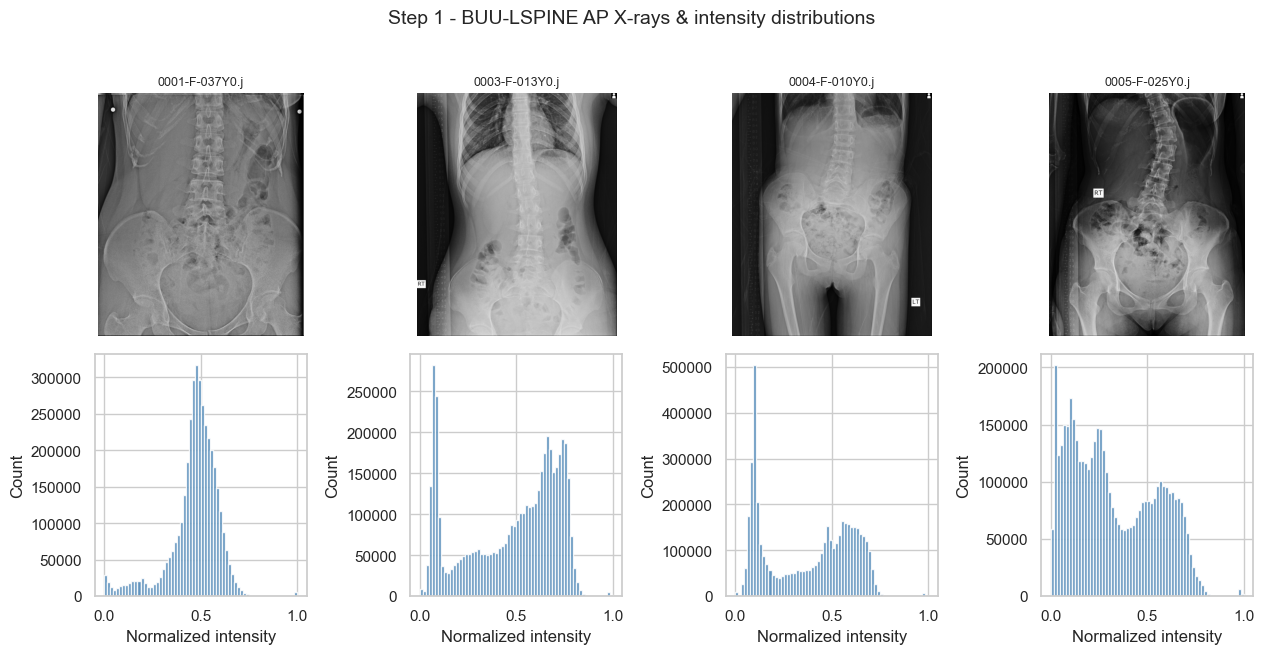

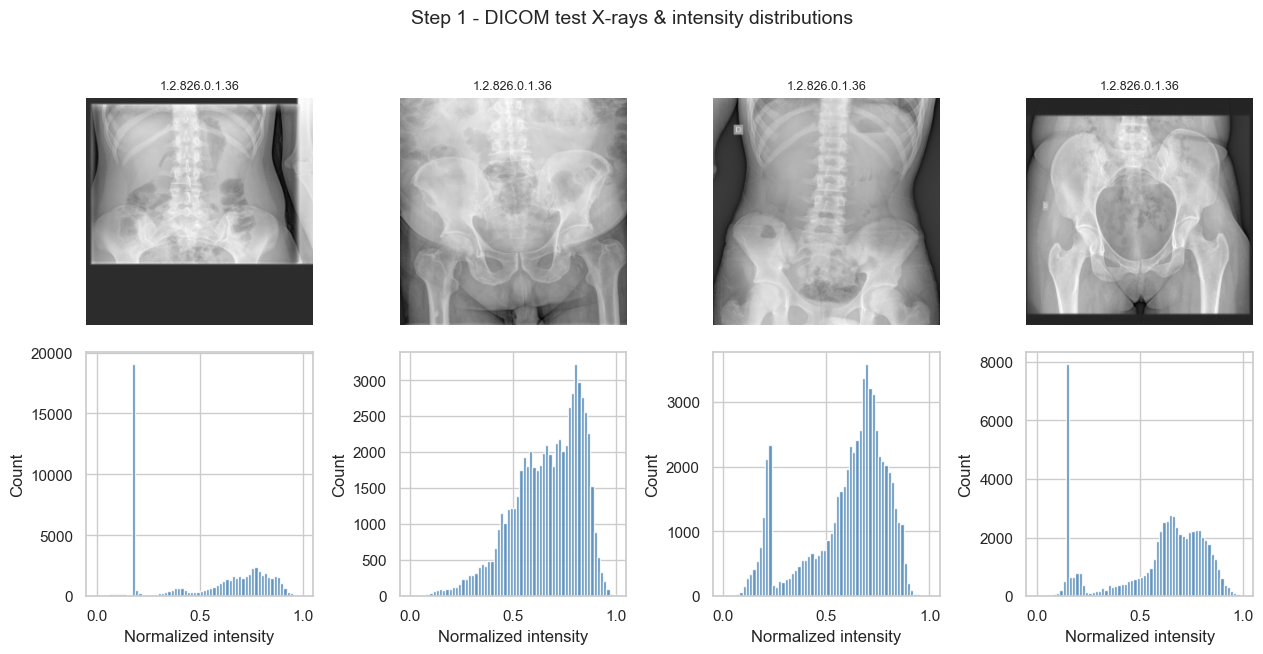

In [4]:
def show_raw_with_histograms(paths, title, savename):
    n = len(paths)
    fig, axes = plt.subplots(2, n, figsize=(3.2 * n, 6.4))
    for k, p in enumerate(paths):
        _, g, _, _ = load_xray(p)
        axes[0, k].imshow(g, cmap="gray"); axes[0, k].set_title(os.path.basename(p)[:14], fontsize=9)
        axes[0, k].axis("off")
        axes[1, k].hist(g.ravel(), bins=64, color="steelblue", alpha=0.85)
        axes[1, k].set_xlabel("Normalized intensity"); axes[1, k].set_ylabel("Count")
    fig.suptitle(title, fontsize=14, y=1.02); plt.tight_layout()
    savefig(fig, savename); plt.show()

show_raw_with_histograms(buu_imgs[:4],
    "Step 1 - BUU-LSPINE AP X-rays & intensity distributions", "step1_buu_samples.png")
if eval_items:
    show_raw_with_histograms(eval_items[:4],
        "Step 1 - DICOM test X-rays & intensity distributions", "step1_dicom_samples.png")

## Step 2 — Train (or load) the YOLO26-seg model on **BUU-LSPINE-2000**

The L4 extractor is a **YOLO26-seg** instance model trained on **BUU-LSPINE-2000 (AP)** (2000 X-rays,
5 vertebra classes L1..L5). The 4-corner CSV labels are converted to YOLO-seg polygons and trained
with a deterministic train/val split.

- **`RETRAIN=False`** (default): reuse `best.pt` if present.
- **`RETRAIN=True`** *or* missing weights (e.g. first run on the new `yolo26m-seg` backbone):
  (re)train from `YOLO_BASE` and write to `runs/segment/ap_seg/l1_l5_yolo26m/weights/best.pt`.

> The **42 DICOMs are a held-out test set** and never enter training or validation here.

In [5]:
import shutil

# ---- CSV (4-corner quads) -> ordered L1..L5 polygons --------------------------
def _csv_rows(path):
    out = []
    for line in open(path):
        nums = re.findall(r"-?\d+\.?\d*", line)
        if len(nums) >= 4:
            out.append([float(v) for v in nums[:4]])    # xL, yL, xR, yR
    return out

def order_quad(pts):
    '''4 points -> [TL, TR, BR, BL] (clockwise, non-self-intersecting).'''
    pts = sorted(pts, key=lambda p: p[1])
    top = sorted(pts[:2], key=lambda p: p[0])
    bot = sorted(pts[2:], key=lambda p: p[0])
    return [top[0], top[1], bot[1], bot[0]]

def parse_polys(path, n_vert=len(CLASS_NAMES), lines_per=2):
    '''Return n_vert quads ordered L1..L5 (top->bottom), or [] if malformed.'''
    rows = _csv_rows(path)
    if len(rows) < lines_per * n_vert:
        return []
    verts = []
    for i in range(n_vert):
        pts = []
        for j in range(lines_per):
            xL, yL, xR, yR = rows[i * lines_per + j]
            pts += [(xL, yL), (xR, yR)]
        q = order_quad(pts)
        verts.append((sum(p[1] for p in q) / 4.0, q))
    verts.sort(key=lambda v: v[0])                      # top -> bottom => L1..L5
    return [q for _, q in verts]

def build_yolo_dataset(root="./yolo_ap_seg", val_ratio=VAL_RATIO, seed=SEED):
    '''Convert BUU-LSPINE labels to a YOLO-seg dataset; return (data.yaml, n_train, n_val).'''
    pairs = []
    for lp in sorted(glob.glob(os.path.join(LBL_DIR, "*.csv"))):
        stem = os.path.splitext(os.path.basename(lp))[0]
        ip = next((os.path.join(IMG_DIR, stem + e) for e in (".jpg", ".jpeg", ".png")
                   if os.path.exists(os.path.join(IMG_DIR, stem + e))), None)
        if ip and len(parse_polys(lp)) == len(CLASS_NAMES):
            pairs.append((ip, lp))
    random.Random(seed).shuffle(pairs)
    n_val = int(len(pairs) * val_ratio)
    split = {"val": pairs[:n_val], "train": pairs[n_val:]}
    for sub in ["images/train", "images/val", "labels/train", "labels/val"]:
        d = os.path.join(root, sub)
        if os.path.exists(d):
            shutil.rmtree(d)
        os.makedirs(d, exist_ok=True)
    for sp, plist in split.items():
        for ip, lp in plist:
            stem = os.path.splitext(os.path.basename(ip))[0]
            H, W = cv2.imread(ip).shape[:2]
            shutil.copy(ip, os.path.join(root, "images", sp, os.path.basename(ip)))
            with open(os.path.join(root, "labels", sp, stem + ".txt"), "w") as f:
                for cid, q in enumerate(parse_polys(lp)):
                    coords = " ".join(f"{x / W:.6f} {y / H:.6f}" for x, y in q)
                    f.write(f"{cid} {coords}\n")
    yaml_path = os.path.join(root, "data.yaml")
    with open(yaml_path, "w") as f:
        f.write(f"path: {os.path.abspath(root)}\ntrain: images/train\nval: images/val\n")
        f.write(f"nc: {len(CLASS_NAMES)}\nnames: {CLASS_NAMES}\n")
    return yaml_path, len(split["train"]), len(split["val"])

# ---- Train (guarded) or reuse existing weights --------------------------------
if RETRAIN or not os.path.exists(YOLO_WEIGHTS):
    print("Preparing YOLO-seg dataset from BUU-LSPINE-2000 ...")
    data_yaml, n_tr, n_va = build_yolo_dataset()
    print(f"  train={n_tr}  val={n_va}  | test DICOMs held out: {len(test_dcm_files)}")
    print(f"Training {YOLO_BASE} for {EPOCHS} epochs @ imgsz={IMGSZ} (batch=auto) ...")
    YOLO(YOLO_BASE).train(data=data_yaml, epochs=EPOCHS, imgsz=IMGSZ, batch=-1,
                          project=YOLO_PROJECT, name=YOLO_NAME, patience=20,
                          workers=0, seed=SEED, exist_ok=True)
else:
    print(f"Reusing existing weights -> {YOLO_WEIGHTS}  (set RETRAIN=True to retrain).")

assert os.path.exists(YOLO_WEIGHTS), f"Training did not produce weights at {YOLO_WEIGHTS}"
seg = YOLO(YOLO_WEIGHTS)
print("Loaded YOLO26-seg:", YOLO_WEIGHTS)

Reusing existing weights -> runs/segment/ap_seg\l1_l5_yolo26m\weights\best.pt  (set RETRAIN=True to retrain).
Loaded YOLO26-seg: runs/segment/ap_seg\l1_l5_yolo26m\weights\best.pt


### Step 2b — Training & Validation diagnostics (BUU-LSPINE val set)

These are the **in-domain** results on the BUU-LSPINE validation split, recovered from the saved run
directory. With `RETRAIN=False` the training cell only reloads `best.pt`, so Ultralytics never
re-emits its plots — we surface them here (training curves, confusion matrix, PR curve, val-batch
predictions) so the validation result is always visible. Figures copied to `figures/step2b_*`.

In [6]:
RUN_DIR = os.path.join(YOLO_PROJECT, YOLO_NAME)

# (1) Final validation metrics (last row of results.csv)
rc_path = os.path.join(RUN_DIR, "results.csv")
if os.path.exists(rc_path):
    rdf = pd.read_csv(rc_path); rdf.columns = [c.strip() for c in rdf.columns]
    last = rdf.iloc[-1]
    print(f"BUU-LSPINE held-out VALIDATION (epoch {int(last['epoch'])} -> best.pt):")
    for k, lbl in [("metrics/precision(M)", "Mask precision"),
                   ("metrics/recall(M)",    "Mask recall"),
                   ("metrics/mAP50(M)",     "Mask mAP@50"),
                   ("metrics/mAP50-95(M)",  "Mask mAP@50-95")]:
        if k in rdf.columns:
            print(f"  {lbl:16s}: {last[k]:.4f}")
    print("  (IN-DOMAIN BUU metrics. The DICOM test set is evaluated separately in Step 4.)")
else:
    print(f"[note] {rc_path} not found -> train at least once (RETRAIN=True) to generate it.")

# (2) Optional live re-validation on the BUU val split (only if the dataset still exists)
data_yaml = os.path.join("./yolo_ap_seg", "data.yaml")
if os.path.exists(data_yaml):
    print("\nRunning live seg.val() on the BUU val split ...")
    vm = seg.val(data=data_yaml, split="val", verbose=False)
    try:
        print(f"  live -> Mask mAP@50={vm.seg.map50:.4f}  mAP@50-95={vm.seg.map:.4f}")
    except Exception:
        pass
else:
    print(f"\n[note] {data_yaml} absent (dataset not rebuilt this session) -> showing saved plots only.")

# (3) Display + save the diagnostic images
def _show_run_imgs(names, title, savename, ncol=2, h=5.5):
    paths = [(n, os.path.join(RUN_DIR, n)) for n in names
             if os.path.exists(os.path.join(RUN_DIR, n))]
    if not paths:
        print(f"[note] none of {names} found in {RUN_DIR}"); return
    nrow = int(np.ceil(len(paths) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(7.0 * ncol, h * nrow))
    axes = np.atleast_1d(axes).ravel()
    for a in axes: a.axis("off")
    for a, (n, p) in zip(axes, paths):
        a.imshow(mpimg.imread(p)); a.set_title(n, fontsize=9); a.axis("off")
    fig.suptitle(title, fontsize=13); plt.tight_layout()
    savefig(fig, savename); plt.show()

_show_run_imgs(["results.png"], "Step 2b - BUU training curves (losses & mAP over epochs)",
               "step2b_training_curves.png", ncol=1, h=7)
_show_run_imgs(["confusion_matrix_normalized.png", "MaskPR_curve.png"],
               "Step 2b - Validation: normalized confusion matrix & Mask PR curve",
               "step2b_val_metrics.png")
_show_run_imgs(["val_batch0_labels.jpg", "val_batch0_pred.jpg"],
               "Step 2b - BUU val batch: ground truth (left) vs prediction (right)",
               "step2b_val_batch.png")

[note] runs/segment/ap_seg\l1_l5_yolo26m\results.csv not found -> train at least once (RETRAIN=True) to generate it.

Running live seg.val() on the BUU val split ...
Ultralytics 8.4.60  Python-3.12.13 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
YOLO26m-seg summary (fused): 149 layers, 23,511,323 parameters, 0 gradients, 121.2 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2079.3412.0 MB/s, size: 1086.3 KB)
val: Scanning C:\Users\csm02\Desktop\edward\bmd\src\BMD\model\yolo_ap_seg\labels\val.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 2.5it/s 7.6s0.3s
                   all        300       1500      0.952      0.951      0.981      0.827      0.952       0.95      0.981      0.784
Speed: 1.0ms preprocess, 18.8ms inference, 0.0ms loss, 0.7ms postproce

### L4 extraction & visualization

The trained model detects L1–L5 as instances. The L4 mask is chosen by **class** when available, else
by the **4th-from-top** rule (vertebrae ordered by vertical centroid). A single `yolo_l4()` helper
returns the selected L4 mask, the status, **all** instance masks, and the raw result — every later
step reuses it (no duplicated inference helpers).

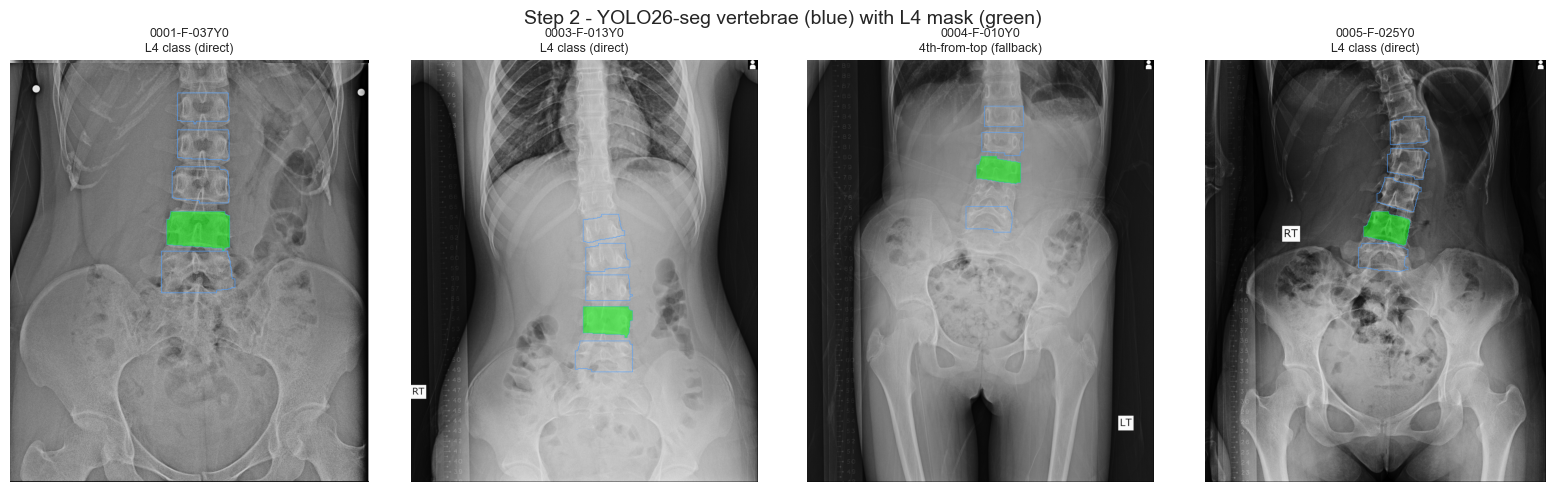

In [7]:
def poly_to_mask(poly_xy, H, W, shrink=1.0):
    poly = np.asarray(poly_xy, np.float32)
    if shrink != 1.0 and len(poly):
        ctr = poly.mean(0); poly = ctr + shrink * (poly - ctr)
    m = np.zeros((H, W), np.uint8)
    if len(poly):
        cv2.fillPoly(m, [poly.astype(np.int32)], 1)
    return m

def pick_l4_index(boxes_xyxy, classes, confs):
    '''Choose the L4 instance: direct class, else 4th vertebra from the top (fallback).'''
    if len(boxes_xyxy) == 0:
        return None, "no detection"
    idx = [i for i, c in enumerate(classes) if c == L4_IDX]
    if idx:
        return max(idx, key=lambda i: confs[i]), "L4 class (direct)"
    order = sorted(range(len(boxes_xyxy)), key=lambda i: (boxes_xyxy[i][1] + boxes_xyxy[i][3]) / 2)
    if len(order) >= 4:
        return order[3], "4th-from-top (fallback)"
    return None, f"only {len(boxes_xyxy)} vertebrae"

def yolo_l4(rgb, conf=CONF, shrink=1.0):
    '''Run YOLO once. Return (l4_mask|None, status, all_instance_masks, result).'''
    r = seg.predict(rgb, conf=conf, verbose=False)[0]
    H, W = rgb.shape[:2]
    if r.masks is None or len(r.boxes) == 0:
        return None, "no detection", [], r
    boxes   = r.boxes.xyxy.cpu().numpy()
    classes = r.boxes.cls.cpu().numpy().astype(int)
    confs   = r.boxes.conf.cpu().numpy()
    inst = [poly_to_mask(r.masks.xy[i], H, W, shrink) for i in range(len(r.masks.xy))]
    i, status = pick_l4_index(boxes, classes, confs)
    return (inst[i] if i is not None else None), status, inst, r

# ---- Visualization: YOLO segmentation with L4 highlighted ----
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for k, p in enumerate(buu_imgs[:4]):
    rgb, _, H, W = load_xray(p)
    m, status, inst, r = yolo_l4(rgb)
    vis = rgb.copy()
    if r.masks is not None:
        for poly in r.masks.xy:
            cv2.polylines(vis, [poly.astype(np.int32)], True, (80, 160, 255), 2)
    if m is not None:
        vis[m > 0] = (0.5 * vis[m > 0] + 0.5 * np.array([0, 255, 0])).astype(np.uint8)
    axes[k].imshow(vis); axes[k].set_title(f"{os.path.basename(p)[:12]}\n{status}", fontsize=9)
    axes[k].axis("off")
fig.suptitle("Step 2 - YOLO26-seg vertebrae (blue) with L4 mask (green)", fontsize=14)
plt.tight_layout(); savefig(fig, "step2_l4_extraction.png"); plt.show()

## Step 3 — BMD & GLCM Extractors

In [8]:
def shrink_mask(mask, shrink=ROI_SHRINK):
    if shrink >= 1.0:
        return mask
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return mask
    cx, cy = xs.mean(), ys.mean()
    out = np.zeros_like(mask)
    nx = np.clip((cx + shrink * (xs - cx)).astype(int), 0, mask.shape[1] - 1)
    ny = np.clip((cy + shrink * (ys - cy)).astype(int), 0, mask.shape[0] - 1)
    out[ny, nx] = 1
    return cv2.morphologyEx(out, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))

def compute_bmd(img_norm, mask):
    vals = img_norm[mask > 0]
    if vals.size == 0:
        return None
    return {"area_px": int(vals.size), "bmd_mean": float(vals.mean()),
            "bmd_median": float(np.median(vals)), "bmd_std": float(vals.std()),
            "bmd_p10": float(np.percentile(vals, 10)), "bmd_p90": float(np.percentile(vals, 90))}

def compute_glcm(img_norm, mask, levels=GLCM_LEVELS):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
    roi  = (img_norm[y0:y1, x0:x1] * (levels - 1)).astype(np.uint8)
    mroi = mask[y0:y1, x0:x1]
    roi[mroi == 0] = 0
    glcm = graycomatrix(roi, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=levels, symmetric=True, normed=True)
    return {"glcm_contrast": float(graycoprops(glcm, "contrast").mean()),
            "glcm_correlation": float(graycoprops(glcm, "correlation").mean()),
            "glcm_energy": float(graycoprops(glcm, "energy").mean()),
            "glcm_homogeneity": float(graycoprops(glcm, "homogeneity").mean())}

def load_test_gt_l4(dcm_path, H, W):
    '''Binary L4 ground-truth mask (PNG) resized to (H, W).'''
    stem = os.path.splitext(os.path.basename(dcm_path))[0]
    p = os.path.join(TEST_MASK_DIR, stem + ".png")
    if not os.path.exists(p):
        return None
    fg = (cv2.imread(p).sum(axis=2) > 10).astype(np.uint8)
    return cv2.resize(fg, (W, H), interpolation=cv2.INTER_NEAREST)
print("Helpers ready.")

Helpers ready.


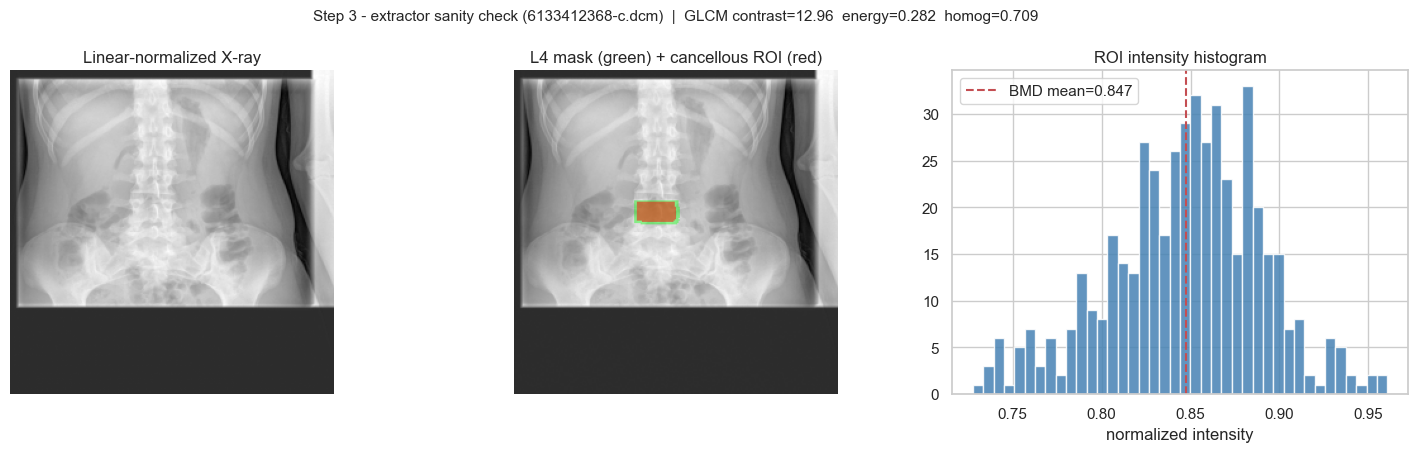

In [9]:
# ---- Step 3 demo - eye-check the BMD/GLCM extractor on one detected L4 ----
if eval_items:
    _p = eval_items[0]
    _rgb, _gl, _H, _W = load_xray(_p)
    _m, _st, _inst, _r = yolo_l4(_rgb)
    if _m is not None and _m.sum():
        _roi  = shrink_mask(_m)
        _bmd  = compute_bmd(_gl, _roi)
        _glcm = compute_glcm(_gl, _roi)
        _vis = cv2.cvtColor((_gl * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
        _vis[_m   > 0] = (0.6 * _vis[_m   > 0] + 0.4 * np.array([0, 255, 0])).astype(np.uint8)
        _vis[_roi > 0] = (0.5 * _vis[_roi > 0] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)
        fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
        ax[0].imshow(_gl, cmap="gray"); ax[0].set_title("Linear-normalized X-ray"); ax[0].axis("off")
        ax[1].imshow(_vis); ax[1].set_title("L4 mask (green) + cancellous ROI (red)"); ax[1].axis("off")
        ax[2].hist(_gl[_roi > 0].ravel(), bins=40, color="steelblue", alpha=0.85)
        ax[2].axvline(_bmd["bmd_mean"], color="r", ls="--", label=f"BMD mean={_bmd['bmd_mean']:.3f}")
        ax[2].set_title("ROI intensity histogram"); ax[2].set_xlabel("normalized intensity"); ax[2].legend()
        fig.suptitle(f"Step 3 - extractor sanity check ({os.path.basename(_p)[-16:]})  |  "
                     f"GLCM contrast={_glcm['glcm_contrast']:.2f}  energy={_glcm['glcm_energy']:.3f}  "
                     f"homog={_glcm['glcm_homogeneity']:.3f}", fontsize=11)
        plt.tight_layout(); savefig(fig, "step3_extractor_sanity.png"); plt.show()
    else:
        print("No L4 detected on the demo image; skipping Step 3 sanity plot.")
else:
    print("No eval_items available for the Step 3 demo.")

## Step 4 — Evaluation on the DICOM Test Set

Evaluated on `dataset-dcm/test/gather` against the **L4 ground-truth masks**, reported **two ways**:

- **(A) Deployed** — Dice / IoU / Precision / Recall of the mask the pipeline actually *names* `L4`
  (the honest real-world inference number; no ground truth used to pick the vertebra).
- **(B) Matched** — Dice of the *best-overlap* detected vertebra vs the GT L4 (isolates segmentation
  quality from *which* vertebra is labelled L4).

A large **(B − A) gap** is the signature of an **L4 naming / indexing** problem on the out-of-domain
DICOM field-of-view — **not** poor segmentation. Metrics CSV → `metrics/`, figures → `figures/`.

In [10]:
def seg_scores(pred, gt, eps=1e-6):
    pred = pred.astype(bool); gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    dice = 2*tp / (2*tp + fp + fn + eps)
    iou  = tp / (tp + fp + fn + eps)
    prec = tp / (tp + fp + eps)
    rec  = tp / (tp + fn + eps)
    return dice, iou, prec, rec, int(tp), int(fp), int(fn)

def best_overlap(inst, gt):
    '''Among ALL detected vertebra instances, the one with the highest Dice vs GT.'''
    if not inst:
        return np.zeros_like(gt), 0.0
    d, m = max(((seg_scores(m, gt)[0], m) for m in inst), key=lambda t: t[0])
    return m, d

# ---- Dual-metric evaluation: (A) Deployed (named L4) vs (B) Matched (best-overlap) ----
rows, bmd_pred, bmd_gt = [], [], []
cm_total = np.zeros((2, 2), dtype=np.int64)
n_fail = 0
for dp in eval_items:
    rgb, gray_lin, H, W = load_xray(dp)
    sel, status, inst, r = yolo_l4(rgb)
    gt = load_test_gt_l4(dp, H, W)
    if gt is None:
        continue
    if sel is None:
        sel = np.zeros((H, W), np.uint8); n_fail += 1
    d, i, p, rc, tp, fp, fn = seg_scores(sel, gt)            # (A) DEPLOYED
    bo_mask, d_match = best_overlap(inst, gt)               # (B) MATCHED
    tn = H*W - (tp + fp + fn)
    cm_total += np.array([[tn, fp], [fn, tp]], dtype=np.int64)
    rows.append({"file": os.path.basename(dp), "status": status, "n_inst": len(inst),
                 "dice": d, "iou": i, "precision": p, "recall": rc, "dice_matched": d_match})
    bp = compute_bmd(gray_lin, shrink_mask(sel)) if sel.sum() else None
    bg = compute_bmd(gray_lin, shrink_mask(gt))
    if bp and bg:
        bmd_pred.append(bp["bmd_mean"]); bmd_gt.append(bg["bmd_mean"])

dfm = pd.DataFrame(rows)
print(f"Evaluated {len(dfm)} test images | L4 detection failures: {n_fail}\n")
print("=== (A) DEPLOYED - mask the model names 'L4'  (honest real-world inference) ===")
for c in ["dice", "iou", "precision", "recall"]:
    print(f"  {c.capitalize():10s}: {dfm[c].mean():.4f} +/- {dfm[c].std():.4f}")
print("\n=== (B) MATCHED - best-overlap vertebra vs GT  (segmentation quality, naming aside) ===")
print(f"  Dice      : {dfm['dice_matched'].mean():.4f} +/- {dfm['dice_matched'].std():.4f}")

n_zero = int((dfm['dice'] < 0.05).sum())
gap = dfm['dice_matched'].mean() - dfm['dice'].mean()
print(f"\n>> Indexing gap (Matched - Deployed Dice) = {gap:.4f}")
print(f">> {n_zero}/{len(dfm)} images have Deployed Dice ~ 0, yet best-overlap reaches mean Dice = "
      f"{dfm.loc[dfm['dice']<0.05, 'dice_matched'].mean():.3f} on those same images.")
dfm.to_csv(os.path.join(METRICS_DIR, "L4_test_segmetrics.csv"), index=False)
print("Saved ->", os.path.join(METRICS_DIR, "L4_test_segmetrics.csv"))

Evaluated 42 test images | L4 detection failures: 8

=== (A) DEPLOYED - mask the model names 'L4'  (honest real-world inference) ===
  Dice      : 0.2836 +/- 0.4105
  Iou       : 0.2515 +/- 0.3708
  Precision : 0.2793 +/- 0.4075
  Recall    : 0.2902 +/- 0.4184

=== (B) MATCHED - best-overlap vertebra vs GT  (segmentation quality, naming aside) ===
  Dice      : 0.6789 +/- 0.3068

>> Indexing gap (Matched - Deployed Dice) = 0.3953
>> 28/42 images have Deployed Dice ~ 0, yet best-overlap reaches mean Dice = 0.593 on those same images.
Saved -> ./l4_v6_output\metrics\L4_test_segmetrics.csv


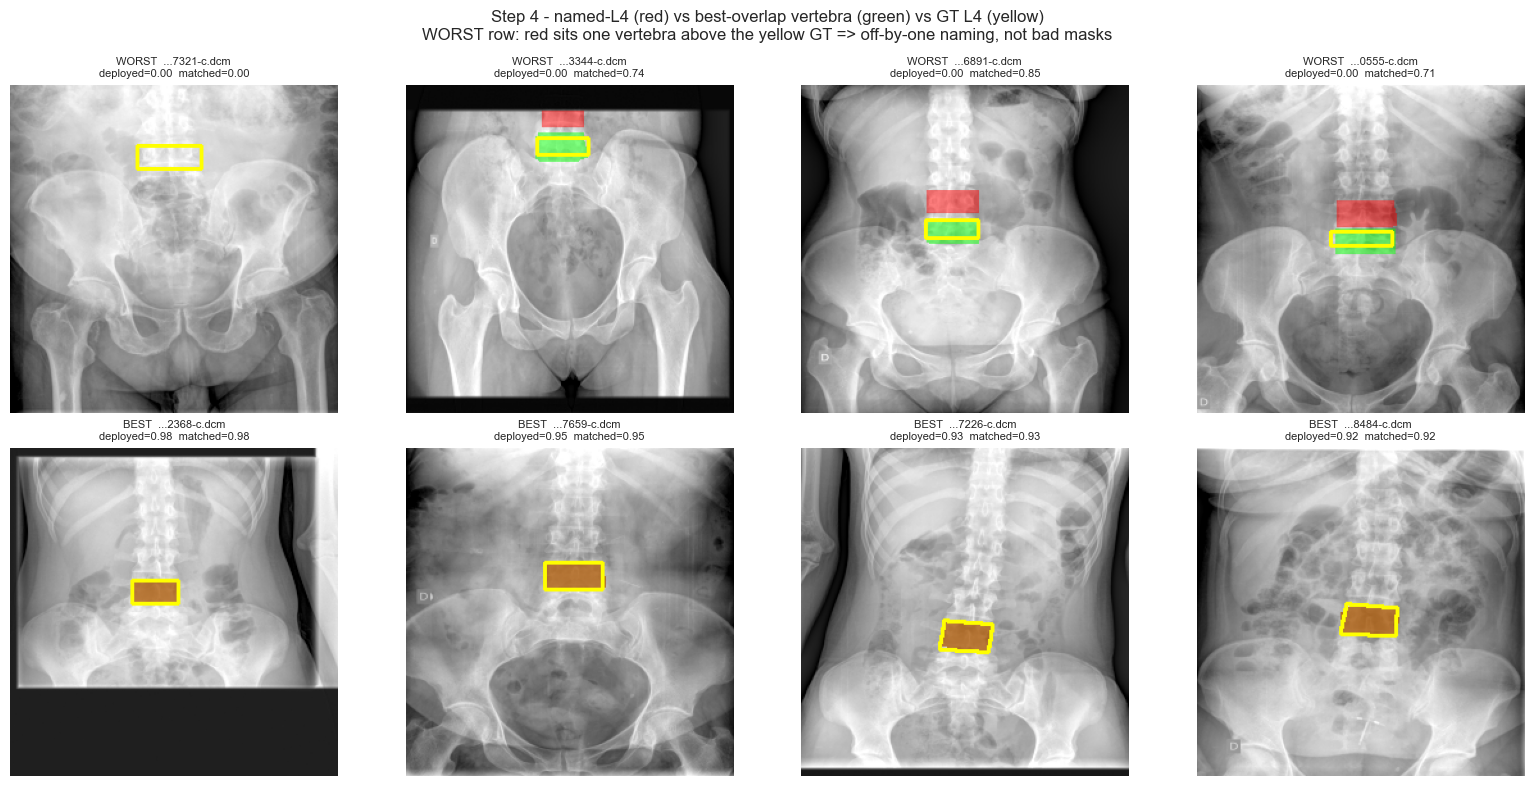

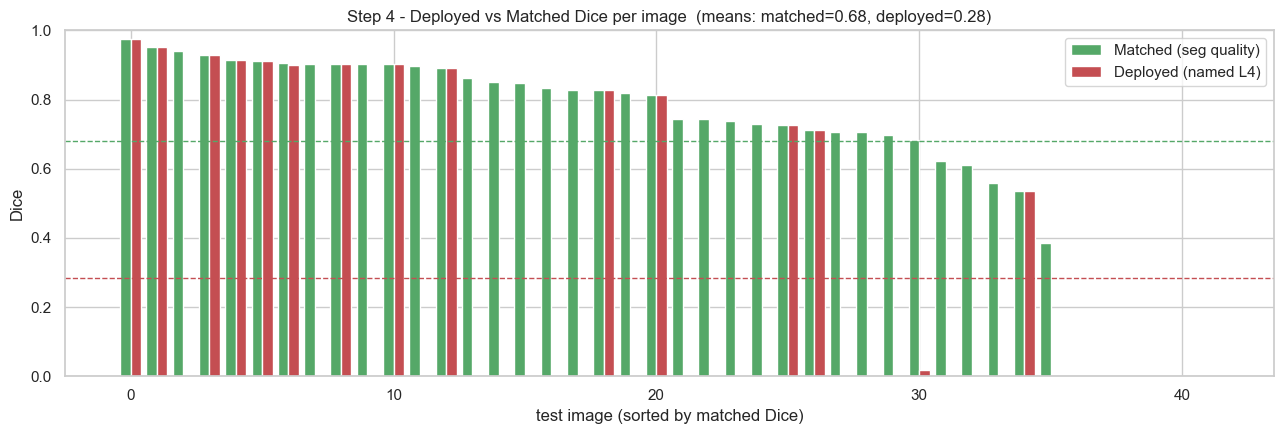

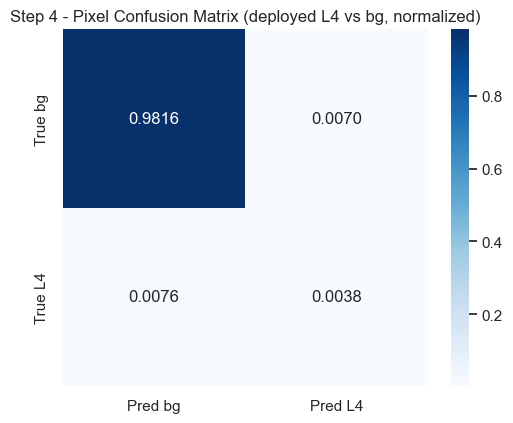

In [11]:
# ---- (1) Diagnostic overlays: where does the 'L4' name land vs the true L4? ----
# red = named 'L4' (deployed)   green = best-overlap vertebra (matched)   yellow = GT L4 contour
worst = dfm.sort_values("dice").head(4)["file"].tolist()
best  = dfm.sort_values("dice", ascending=False).head(4)["file"].tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for k, fname in enumerate(worst + best):
    dp = next(p for p in eval_items if os.path.basename(p) == fname)
    rgb, _, H, W = load_xray(dp)
    sel, status, inst, r = yolo_l4(rgb)
    gt = load_test_gt_l4(dp, H, W)
    bo_mask, d_match = best_overlap(inst, gt)
    vis = rgb.copy()
    if bo_mask is not None and bo_mask.sum():
        vis[bo_mask > 0] = (0.5*vis[bo_mask > 0] + 0.5*np.array([0, 255, 0])).astype(np.uint8)
    if sel is not None and sel.sum():
        vis[sel > 0]     = (0.5*vis[sel > 0]     + 0.5*np.array([255, 0, 0])).astype(np.uint8)
    if gt is not None:
        cnts, _ = cv2.findContours(gt, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(vis, cnts, -1, (255, 255, 0), 2)
    row = dfm[dfm.file == fname].iloc[0]
    ax = axes[k//4, k % 4]
    ax.imshow(vis); ax.axis("off")
    ax.set_title(f"{'WORST' if k < 4 else 'BEST'}  ...{fname[-10:]}\n"
                 f"deployed={row['dice']:.2f}  matched={row['dice_matched']:.2f}", fontsize=8)
fig.suptitle("Step 4 - named-L4 (red) vs best-overlap vertebra (green) vs GT L4 (yellow)\n"
             "WORST row: red sits one vertebra above the yellow GT => off-by-one naming, not bad masks",
             fontsize=12)
plt.tight_layout(); savefig(fig, "step4_overlays.png"); plt.show()

# ---- (2) Per-image Deployed vs Matched Dice ----
order = dfm.sort_values("dice_matched", ascending=False).reset_index(drop=True)
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(x - 0.2, order["dice_matched"], width=0.4, label="Matched (seg quality)", color="#55A868")
ax.bar(x + 0.2, order["dice"],         width=0.4, label="Deployed (named L4)",   color="#C44E52")
ax.axhline(order["dice_matched"].mean(), color="#55A868", ls="--", lw=1)
ax.axhline(order["dice"].mean(),         color="#C44E52", ls="--", lw=1)
ax.set_xlabel("test image (sorted by matched Dice)"); ax.set_ylabel("Dice"); ax.set_ylim(0, 1)
ax.set_title(f"Step 4 - Deployed vs Matched Dice per image  "
             f"(means: matched={order['dice_matched'].mean():.2f}, deployed={order['dice'].mean():.2f})")
ax.legend(); plt.tight_layout(); savefig(fig, "step4_deployed_vs_matched.png"); plt.show()

# ---- (3) Pixel confusion matrix (deployed L4 vs background) ----
fig, ax = plt.subplots(figsize=(5.2, 4.4))
sns.heatmap(cm_total / cm_total.sum(), annot=True, fmt=".4f", cmap="Blues",
            xticklabels=["Pred bg", "Pred L4"], yticklabels=["True bg", "True L4"], ax=ax)
ax.set_title("Step 4 - Pixel Confusion Matrix (deployed L4 vs bg, normalized)")
plt.tight_layout(); savefig(fig, "step4_confusion_matrix.png"); plt.show()

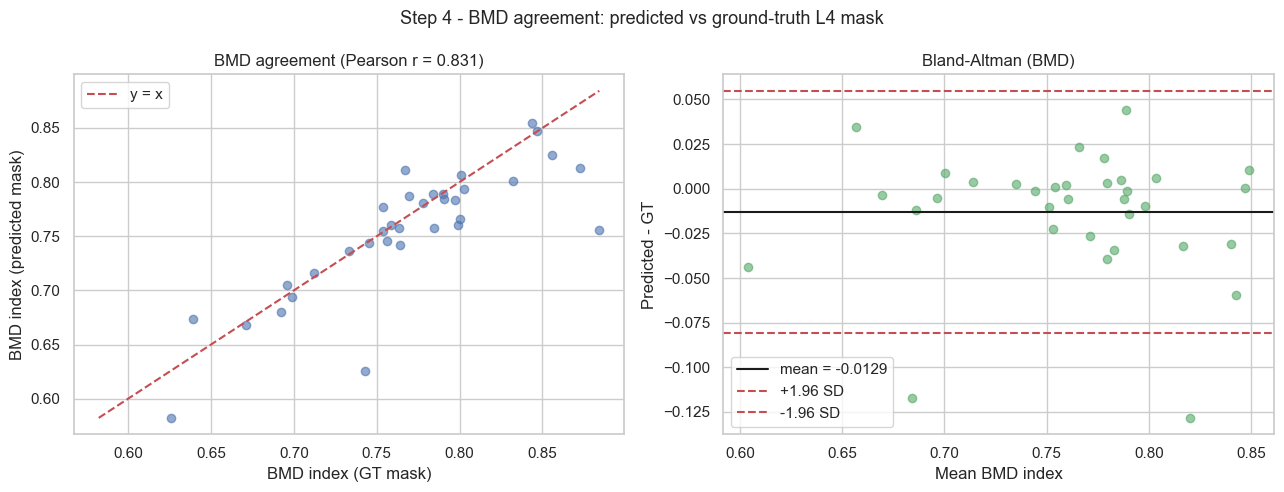

In [12]:
# ---- Bland-Altman + correlation of BMD (predicted vs GT mask) ----
bmd_pred = np.array(bmd_pred); bmd_gt = np.array(bmd_gt)
if len(bmd_gt) >= 2:
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    ax[0].scatter(bmd_gt, bmd_pred, alpha=0.6, color="#4C72B0")
    lims = [min(bmd_gt.min(), bmd_pred.min()), max(bmd_gt.max(), bmd_pred.max())]
    ax[0].plot(lims, lims, "r--", label="y = x")
    r = np.corrcoef(bmd_gt, bmd_pred)[0, 1]
    ax[0].set_title(f"BMD agreement (Pearson r = {r:.3f})")
    ax[0].set_xlabel("BMD index (GT mask)"); ax[0].set_ylabel("BMD index (predicted mask)"); ax[0].legend()
    mean_b = (bmd_pred + bmd_gt) / 2.0; diff_b = bmd_pred - bmd_gt
    mdv, sdv = diff_b.mean(), diff_b.std()
    ax[1].scatter(mean_b, diff_b, alpha=0.6, color="#55A868")
    ax[1].axhline(mdv, color="k", label=f"mean = {mdv:.4f}")
    ax[1].axhline(mdv + 1.96*sdv, color="r", ls="--", label="+1.96 SD")
    ax[1].axhline(mdv - 1.96*sdv, color="r", ls="--", label="-1.96 SD")
    ax[1].set_xlabel("Mean BMD index"); ax[1].set_ylabel("Predicted - GT")
    ax[1].set_title("Bland-Altman (BMD)"); ax[1].legend()
    fig.suptitle("Step 4 - BMD agreement: predicted vs ground-truth L4 mask", fontsize=13)
    plt.tight_layout(); savefig(fig, "step4_bland_altman.png"); plt.show()
else:
    print("Not enough paired BMD samples for a Bland-Altman plot.")

## Step 5 — Modular Inference (pre-trained model)

`infer_l4(path)` accepts any raw X-ray (**JPG/PNG or DICOM**), runs YOLO segmentation, and returns +
plots the **L4 BMD and GLCM** metrics. Per-sample figures saved to `figures/step5_*`.

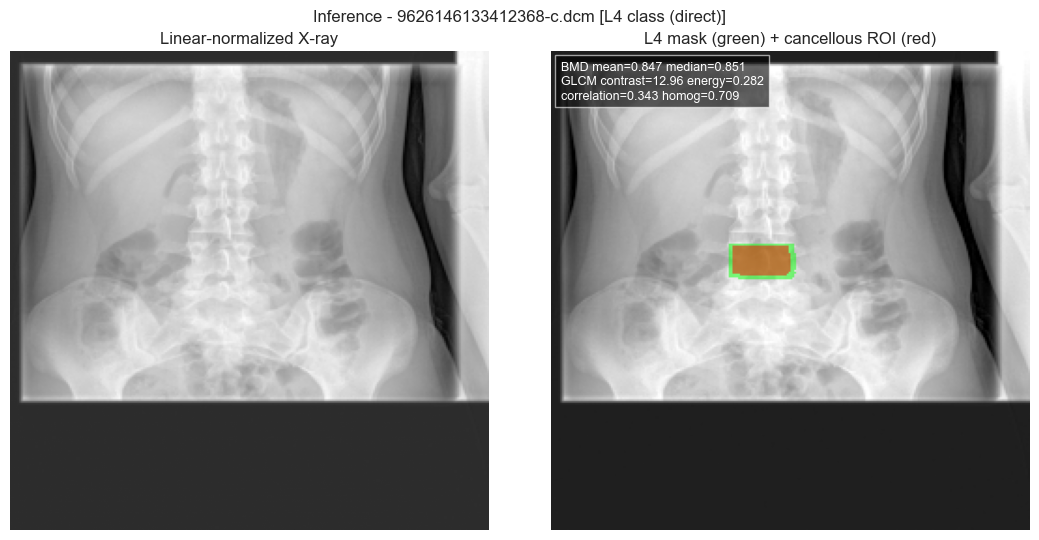

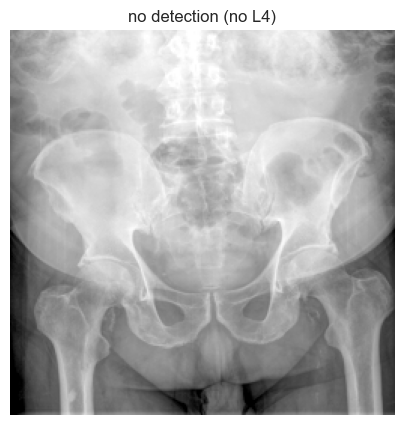

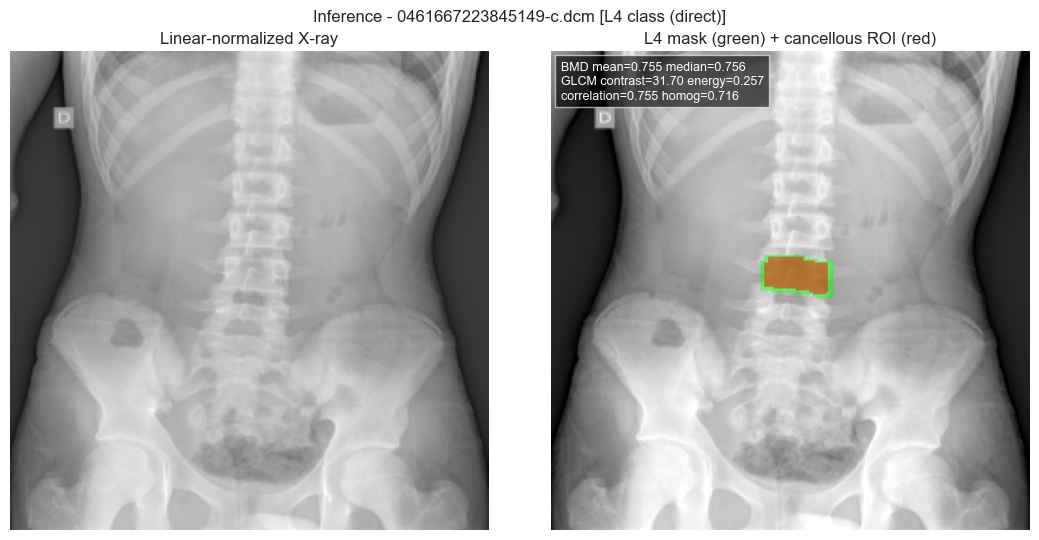

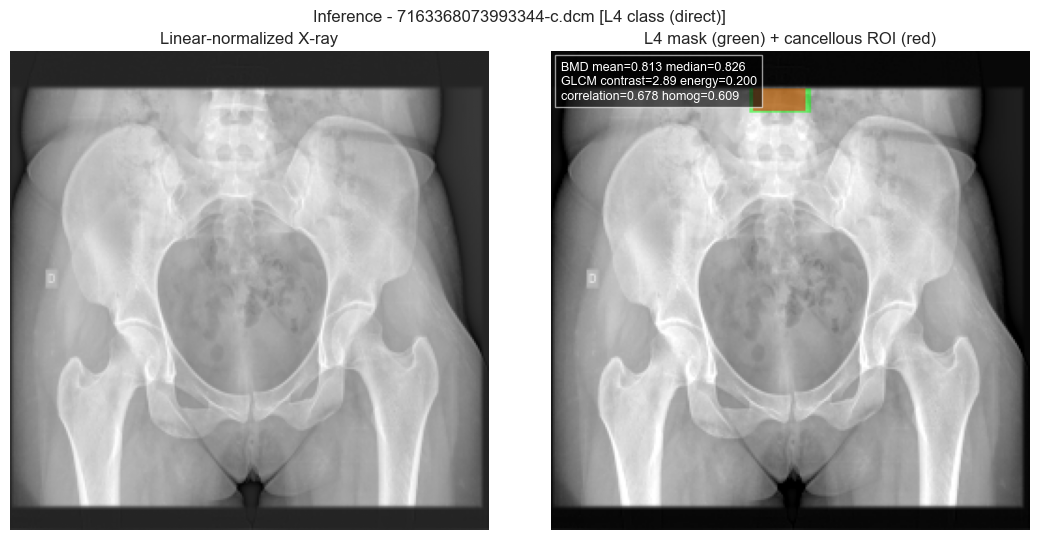

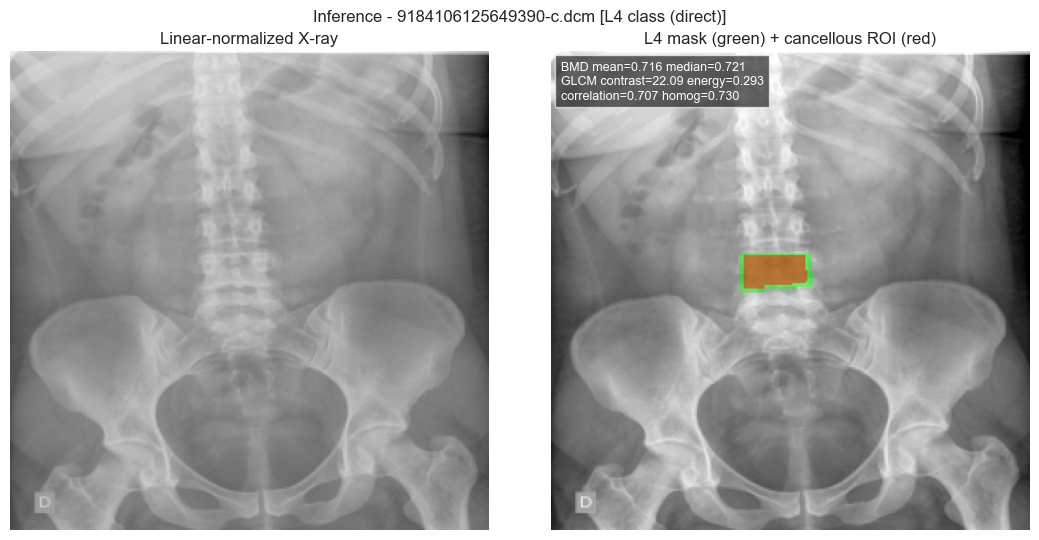

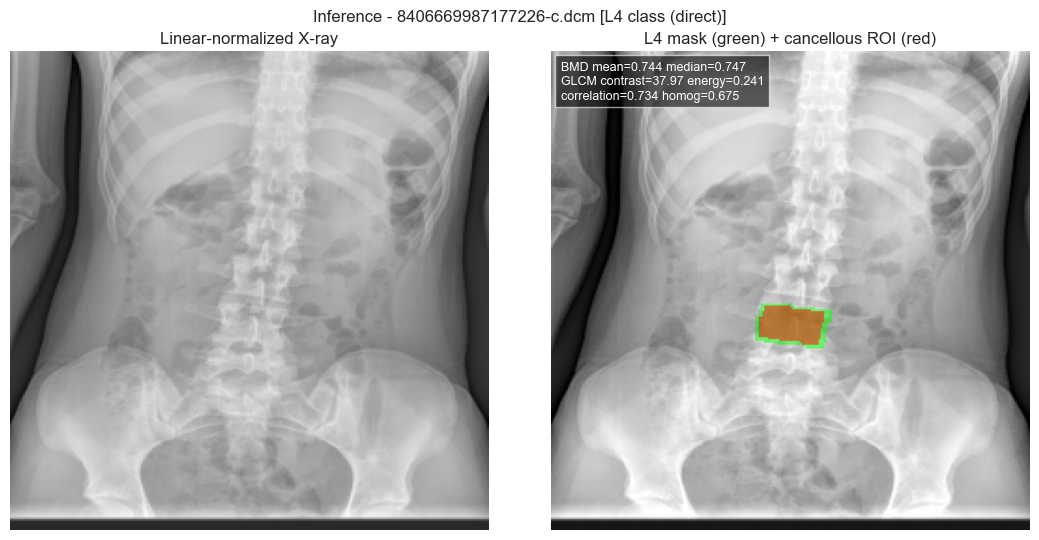

Saved metrics for 42 images -> ./l4_v6_output\metrics\L4_test_metrics.csv


,file,status,area_px,bmd_mean,bmd_median,bmd_std,bmd_p10,bmd_p90,glcm_contrast,glcm_correlation,glcm_energy,glcm_homogeneity
0,1.2.826.0.1.3680043.8.498.10406657579016312201...,L4 class (direct),485.0,0.847281,0.851116,0.043026,0.788694,0.898200,12.961613,0.343225,0.282023,0.708568
1,1.2.826.0.1.3680043.8.498.10947130043296900260...,no detection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.11121020226184051416...,L4 class (direct),568.0,0.754717,0.755742,0.043349,0.693319,0.811490,31.702147,0.755215,0.257003,0.716090
3,1.2.826.0.1.3680043.8.498.11207126462590105123...,L4 class (direct),336.0,0.813185,0.825561,0.074968,0.726991,0.894987,2.890362,0.677976,0.199663,0.609144
4,1.2.826.0.1.3680043.8.498.11227155170490832168...,L4 class (direct),549.0,0.715949,0.721033,0.039212,0.659665,0.763265,22.093369,0.706825,0.292818,0.729731
5,1.2.826.0.1.3680043.8.498.11430185427783861938...,L4 class (direct),593.0,0.743752,0.747446,0.051404,0.665353,0.802897,37.971324,0.734324,0.241306,0.675047
6,1.2.826.0.1.3680043.8.498.11479964994316715381...,L4 class (direct),646.0,0.806412,0.815067,0.055093,0.723004,0.872994,28.916213,0.585604,0.217862,0.674647
7,1.2.826.0.1.3680043.8.498.11666143137939211262...,L4 class (direct),597.0,0.736083,0.738795,0.058369,0.657080,0.813505,14.845286,0.655441,0.187472,0.597593
8,1.2.826.0.1.3680043.8.498.12209232711532162247...,no detection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.2.826.0.1.3680043.8.498.12608809850577365286...,L4 class (direct),525.0,0.784788,0.792785,0.069324,0.685582,0.865277,1.522829,0.822529,0.200712,0.628537


In [13]:
def infer_l4(path, show=True, savename=None):
    rgb, gray_lin, H, W = load_xray(path)
    m, status, inst, r = yolo_l4(rgb)
    metrics = {"file": os.path.basename(path), "status": status}
    if m is None or m.sum() == 0:
        if show:
            fig = plt.figure(figsize=(5, 5)); plt.imshow(rgb)
            plt.title(f"{status} (no L4)"); plt.axis("off")
            if savename: savefig(fig, savename)
            plt.show()
        return metrics
    roi = shrink_mask(m)
    bmd = compute_bmd(gray_lin, roi); glcm = compute_glcm(gray_lin, roi)
    if bmd:  metrics.update(bmd)
    if glcm: metrics.update(glcm)
    if show:
        vis = rgb.copy()
        vis[m > 0]   = (0.5*vis[m > 0]   + 0.5*np.array([0, 255, 0])).astype(np.uint8)
        vis[roi > 0] = (0.5*vis[roi > 0] + 0.5*np.array([255, 0, 0])).astype(np.uint8)
        fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
        ax[0].imshow(gray_lin, cmap="gray"); ax[0].set_title("Linear-normalized X-ray"); ax[0].axis("off")
        ax[1].imshow(vis); ax[1].axis("off"); ax[1].set_title("L4 mask (green) + cancellous ROI (red)")
        if bmd and glcm:
            txt = (f"BMD mean={bmd['bmd_mean']:.3f} median={bmd['bmd_median']:.3f}\n"
                   f"GLCM contrast={glcm['glcm_contrast']:.2f} energy={glcm['glcm_energy']:.3f}\n"
                   f"correlation={glcm['glcm_correlation']:.3f} homog={glcm['glcm_homogeneity']:.3f}")
            ax[1].text(0.02, 0.98, txt, transform=ax[1].transAxes, va="top", fontsize=9,
                       color="white", bbox=dict(facecolor="black", alpha=0.6))
        fig.suptitle(f"Inference - {os.path.basename(path)[-22:]} [{status}]", fontsize=12)
        plt.tight_layout()
        if savename: savefig(fig, savename)
        plt.show()
    return metrics

results = [infer_l4(p, show=(k < 6), savename=f"step5_infer_{k:02d}.png" if k < 6 else None)
           for k, p in enumerate(eval_items)]
res_df = pd.DataFrame(results)
res_df.to_csv(os.path.join(METRICS_DIR, "L4_test_metrics.csv"), index=False)
print(f"Saved metrics for {len(res_df)} images -> {os.path.join(METRICS_DIR, 'L4_test_metrics.csv')}")
display(res_df.head(10))

## Step 6 — Save Spine/L4 Extraction Results for the Test Set

Every DICOM test image is processed and its extraction artifacts are written to
`l4_v6_output/segmentation/`:
- `<id>_overlay.png` — all detected vertebrae (blue) with the L4 mask (green),
- `<id>_L4mask.png` — the binary L4 mask,
- `L4_extraction_summary.csv` — per-image status + BMD + GLCM metrics.

A gallery of the first saved overlays is shown for a quick visual check.

Saved 42 results to ./l4_v6_output\segmentation (overlays + masks + summary CSV); L4 found in 34/42.


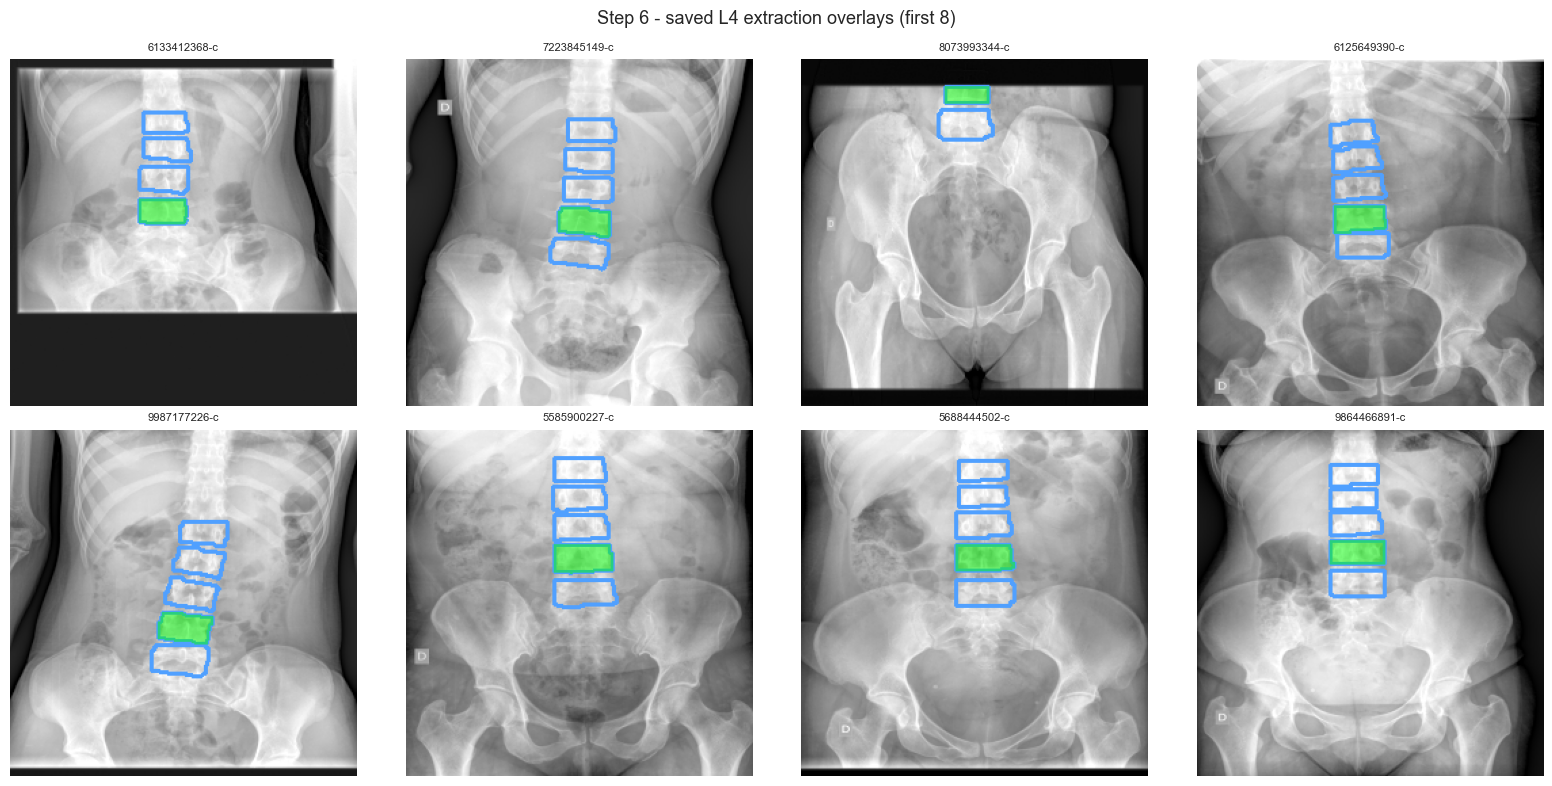

,file,status,area_px,bmd_mean,bmd_median,bmd_std,bmd_p10,bmd_p90,glcm_contrast,glcm_correlation,glcm_energy,glcm_homogeneity
0,1.2.826.0.1.3680043.8.498.10406657579016312201...,L4 class (direct),485.0,0.847281,0.851116,0.043026,0.788694,0.898200,12.961613,0.343225,0.282023,0.708568
1,1.2.826.0.1.3680043.8.498.10947130043296900260...,no detection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.11121020226184051416...,L4 class (direct),568.0,0.754717,0.755742,0.043349,0.693319,0.811490,31.702147,0.755215,0.257003,0.716090
3,1.2.826.0.1.3680043.8.498.11207126462590105123...,L4 class (direct),336.0,0.813185,0.825561,0.074968,0.726991,0.894987,2.890362,0.677976,0.199663,0.609144
4,1.2.826.0.1.3680043.8.498.11227155170490832168...,L4 class (direct),549.0,0.715949,0.721033,0.039212,0.659665,0.763265,22.093369,0.706825,0.292818,0.729731
5,1.2.826.0.1.3680043.8.498.11430185427783861938...,L4 class (direct),593.0,0.743752,0.747446,0.051404,0.665353,0.802897,37.971324,0.734324,0.241306,0.675047
6,1.2.826.0.1.3680043.8.498.11479964994316715381...,L4 class (direct),646.0,0.806412,0.815067,0.055093,0.723004,0.872994,28.916213,0.585604,0.217862,0.674647
7,1.2.826.0.1.3680043.8.498.11666143137939211262...,L4 class (direct),597.0,0.736083,0.738795,0.058369,0.657080,0.813505,14.845286,0.655441,0.187472,0.597593
8,1.2.826.0.1.3680043.8.498.12209232711532162247...,no detection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.2.826.0.1.3680043.8.498.12608809850577365286...,L4 class (direct),525.0,0.784788,0.792785,0.069324,0.685582,0.865277,1.522829,0.822529,0.200712,0.628537


In [14]:
save_rows, gallery = [], []
for dp in test_dcm_files:
    stem = os.path.splitext(os.path.basename(dp))[0]
    rgb, gray_lin, H, W = load_xray(dp)
    m, status, inst, r = yolo_l4(rgb)
    rec = {"file": os.path.basename(dp), "status": status}
    if m is not None and m.sum() > 0:
        roi  = shrink_mask(m)
        bmd  = compute_bmd(gray_lin, roi); glcm = compute_glcm(gray_lin, roi)
        if bmd:  rec.update(bmd)
        if glcm: rec.update(glcm)
        vis = rgb.copy()
        if r.masks is not None:
            for poly in r.masks.xy:
                cv2.polylines(vis, [poly.astype(np.int32)], True, (80, 160, 255), 2)
        vis[m > 0] = (0.5*vis[m > 0] + 0.5*np.array([0, 255, 0])).astype(np.uint8)
        cv2.imwrite(os.path.join(SEG_DIR, stem + "_overlay.png"), cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))
        cv2.imwrite(os.path.join(SEG_DIR, stem + "_L4mask.png"), (m * 255).astype(np.uint8))
        if len(gallery) < 8:
            gallery.append((stem, vis))
    save_rows.append(rec)

summary = pd.DataFrame(save_rows)
summary.to_csv(os.path.join(SEG_DIR, "L4_extraction_summary.csv"), index=False)
n_ok = int(summary["status"].astype(str).str.contains("L4|4th").sum())
print(f"Saved {len(summary)} results to {SEG_DIR} (overlays + masks + summary CSV); "
      f"L4 found in {n_ok}/{len(summary)}.")

# ---- Gallery visualization of the saved overlays ----
if gallery:
    ncol = 4; nrow = int(np.ceil(len(gallery) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4*ncol, 4*nrow))
    axes = np.atleast_1d(axes).ravel()
    for a in axes: a.axis("off")
    for a, (stem, vis) in zip(axes, gallery):
        a.imshow(vis); a.set_title(stem[-12:], fontsize=8); a.axis("off")
    fig.suptitle("Step 6 - saved L4 extraction overlays (first 8)", fontsize=13)
    plt.tight_layout(); savefig(fig, "step6_extraction_gallery.png"); plt.show()
display(summary.head(10))

## Step 7 — Export to **ONNX** for the Web Project

The trained `best.pt` is exported to **ONNX** so the web project (e.g. `onnxruntime-web` /
`onnxruntime`) can run L4 segmentation without PyTorch.

> **Note on the sample code.** The provided snippet used `optimize=True`, but in Ultralytics
> `optimize` is a **TorchScript-only** flag (mobile) and is not valid for ONNX. The web-correct
> options are `simplify=True` (graph slimming via onnxslim) with a broadly-compatible `opset=12`,
> static `imgsz=640`. We then **validate** by loading the exported `.onnx` back through Ultralytics
> and visualizing **ONNX vs PyTorch** L4 masks side-by-side (a parity check) and `onnxruntime`
> I/O signatures the web app will bind to.

Ultralytics 8.4.60  Python-3.12.13 torch-2.12.0.dev20260408+cu128 CPU (13th Gen Intel Core i7-13620H)

PyTorch: starting from 'runs\segment\ap_seg\l1_l5_yolo26m\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 300, 38), (1, 32, 160, 160)) (206.7 MB)

ONNX: starting export with onnx 1.22.0 opset 12...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  2.6s, saved as 'runs\segment\ap_seg\l1_l5_yolo26m\weights\best.onnx' (90.0 MB)

Export complete (3.5s)
Results saved to C:\Users\csm02\Desktop\edward\bmd\src\BMD\model\runs\segment\ap_seg\l1_l5_yolo26m\weights\best.onnx
Predict:         yolo predict task=segment model=runs\segment\ap_seg\l1_l5_yolo26m\weights\best.onnx imgsz=640 
Validate:        yolo val task=segment model=runs\segment\ap_seg\l1_l5_yolo26m\weights\best.onnx imgsz=640 data=yolo_ap_seg\data.yaml  
Visualize:       https://netron.app
Exported ONNX: runs\segment\ap_seg\l1_l5_yolo26m\weights\best.onnx
Copied to    : ./l4_v6_output\expo

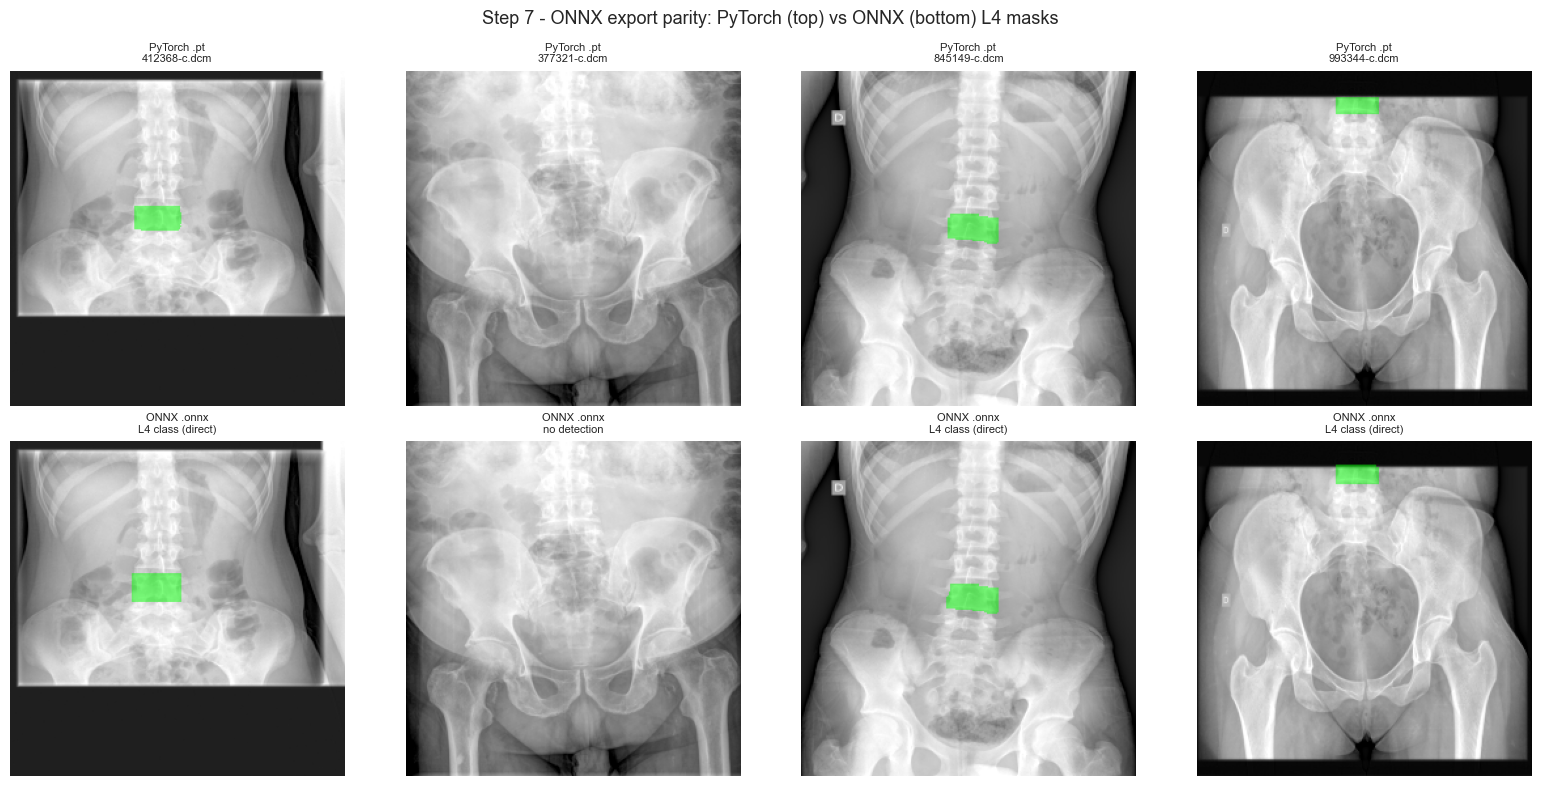

In [15]:
# ---- (1) Export best.pt -> ONNX (web-ready) ----
onnx_src = seg.export(format="onnx", opset=12, simplify=True, dynamic=False, imgsz=IMGSZ)
onnx_path = os.path.join(EXPORT_DIR, "best.onnx")
shutil.copy(onnx_src, onnx_path)
print(f"Exported ONNX: {onnx_src}")
print(f"Copied to    : {onnx_path}  ({os.path.getsize(onnx_path)/1e6:.1f} MB)")

# ---- (2) onnxruntime I/O signature (what the web app binds to) ----
try:
    import onnxruntime as ort
    sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
    print("\nONNX Runtime I/O (for the web project):")
    for inp in sess.get_inputs():
        print(f"  input : {inp.name:12s} {inp.shape}  {inp.type}")
    for out in sess.get_outputs():
        print(f"  output: {out.name:12s} {out.shape}  {out.type}")
except Exception as e:
    print(f"[note] onnxruntime check skipped: {e}")

# ---- (3) Parity visualization: PyTorch (.pt) vs ONNX (.onnx) L4 masks ----
seg_onnx = YOLO(onnx_path, task="segment")
samples = (eval_items[:4] or buu_imgs[:4])
fig, axes = plt.subplots(2, len(samples), figsize=(4*len(samples), 8))
axes = np.atleast_2d(axes)
for k, p in enumerate(samples):
    rgb, _, H, W = load_xray(p)
    # PyTorch L4 (reuse pipeline helper)
    m_pt, st_pt, _, _ = yolo_l4(rgb)
    vpt = rgb.copy()
    if m_pt is not None: vpt[m_pt > 0] = (0.5*vpt[m_pt > 0] + 0.5*np.array([0,255,0])).astype(np.uint8)
    axes[0, k].imshow(vpt); axes[0, k].axis("off")
    axes[0, k].set_title(f"PyTorch .pt\n{os.path.basename(p)[-12:]}", fontsize=8)
    # ONNX L4 (same selection logic, fresh inference)
    ro = seg_onnx.predict(rgb, conf=CONF, verbose=False)[0]
    von = rgb.copy(); st_on = "no detection"
    if ro.masks is not None and len(ro.boxes):
        boxes = ro.boxes.xyxy.cpu().numpy(); cls = ro.boxes.cls.cpu().numpy().astype(int)
        cf = ro.boxes.conf.cpu().numpy()
        inst = [poly_to_mask(ro.masks.xy[i], H, W) for i in range(len(ro.masks.xy))]
        i, st_on = pick_l4_index(boxes, cls, cf)
        if i is not None:
            von[inst[i] > 0] = (0.5*von[inst[i] > 0] + 0.5*np.array([0,255,0])).astype(np.uint8)
    axes[1, k].imshow(von); axes[1, k].axis("off")
    axes[1, k].set_title(f"ONNX .onnx\n{st_on}", fontsize=8)
fig.suptitle("Step 7 - ONNX export parity: PyTorch (top) vs ONNX (bottom) L4 masks", fontsize=13)
plt.tight_layout(); savefig(fig, "step7_onnx_parity.png"); plt.show()

## 3. Explainable AI

Two complementary explanations.

### XAI 1 — Seg-Grad-CAM (segmentation explanation)
A **gradient-based** Grad-CAM adapted to YOLO-seg (an instance model). The target scalar is the
**L4 instance mask probability** (matched anchor coefficients × prototypes, cropped to the L4 box),
back-propagated to a high-resolution neck layer (P3, stride 8): Grad-CAM = ReLU(Σ_k a_k A_k) with
a_k = mean gradient of the target w.r.t. activation channel k. The **full** panel shows the column-wide
attention; the **L4-focused/zoomed** panels isolate the L4 body and its trabecular structure.

### XAI 2 — BMD-contribution heatmap (measurement explanation)
Since the BMD index is the **mean linear intensity inside the L4 ROI**, the honest explanation of the
*measurement* is the intensity distribution itself — the ROI heatmap + histogram show exactly which
pixels drive the reported value.

RuntimeError: The size of tensor a (291) must match the size of tensor b (32) at non-singleton dimension 0

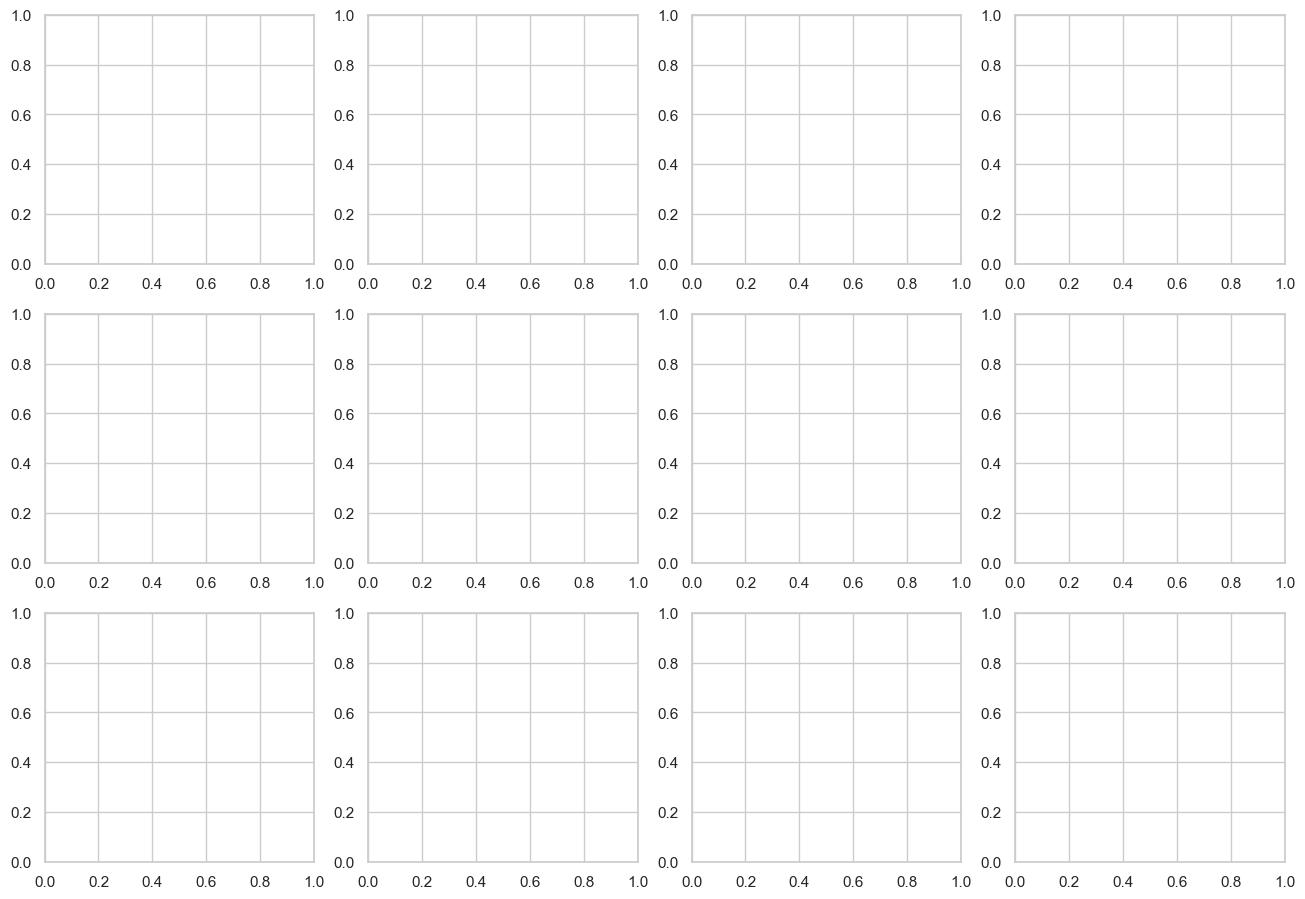

In [ ]:
# ============================================================================
#  XAI 1 - Seg-Grad-CAM (gradient-based) on the L4 instance
# ============================================================================
import torch
from ultralytics.data.augment import LetterBox

# Fresh model for autograd: the pipeline's `seg` has run many predict() calls that cache
# inference-mode buffers which cannot enter an autograd graph. A never-predicted load stays normal.
_NET   = YOLO(YOLO_WEIGHTS).model.eval()
_DEV   = next(_NET.parameters()).device
_IMGSZ = 640
_PROTO = _IMGSZ // 4          # prototype-mask resolution (160)
_CAM_LAYER = 15               # P3 / stride-8 neck feature (highest-res head input)

def l4_focus_weight(mask, ksize=41):
    '''Soft Gaussian weighting around the L4 mask for ROI-focused attribution.'''
    d = cv2.dilate(mask.astype(np.uint8), np.ones((ksize, ksize), np.uint8), 1).astype(np.float32)
    d = cv2.GaussianBlur(d, (ksize, ksize), 0)
    return d / (d.max() + 1e-6)

def seg_grad_cam(img_bgr, layer_idx=_CAM_LAYER, cls_idx=L4_IDX):
    '''Returns (cam[H,W] in [0,1], l4_mask[H,W] bool) in the ORIGINAL image frame.'''
    h0, w0 = img_bgr.shape[:2]
    r = min(_IMGSZ / h0, _IMGSZ / w0)
    nw, nh = round(w0 * r), round(h0 * r)
    pw, ph = (_IMGSZ - nw) // 2, (_IMGSZ - nh) // 2
    im = LetterBox((_IMGSZ, _IMGSZ), auto=False)(image=img_bgr)
    t = torch.from_numpy(im[:, :, ::-1].transpose(2, 0, 1).copy()).float().unsqueeze(0).to(_DEV) / 255.0
    t.requires_grad_(True)

    acts, grads = {}, {}
    layer = _NET.model[layer_idx]
    h1 = layer.register_forward_hook(lambda m, i, o: acts.__setitem__('a', o))
    h2 = layer.register_full_backward_hook(lambda m, gi, go: grads.__setitem__('g', go[0]))
    try:
        _NET.model[-1].shape = None                             # force anchor recompute under autograd
        with torch.enable_grad():
            det, proto = _NET(t)[0]                              # det [1,4+NC+32,A], proto [1,32,160,160]
        nc = len(CLASS_NAMES)
        a = torch.argmax(det[0, 4:4 + nc, :][cls_idx]).item()
        cx, cy, bw, bh = [float(v) for v in det[0, 0:4, a]]
        coeff = det[0, 4 + nc:, a]
        prob = torch.sigmoid((coeff[:, None, None] * proto[0]).sum(0))
        crop = torch.zeros_like(prob)
        x0, y0 = max(0, int((cx - bw / 2) / 4)), max(0, int((cy - bh / 2) / 4))
        x1, y1 = min(_PROTO, int((cx + bw / 2) / 4)), min(_PROTO, int((cy + bh / 2) / 4))
        crop[y0:y1, x0:x1] = 1.0
        prob_l4 = prob * crop
        mfloat = (prob_l4 > 0.5).float().detach()
        if mfloat.sum() < 1:
            mfloat = crop.detach()
        _NET.zero_grad()
        (prob_l4 * mfloat).sum().backward()
        A  = acts['a'][0].detach()
        Gw = grads['g'][0].detach().mean(dim=(1, 2))
        cam = torch.relu((Gw[:, None, None] * A).sum(0)).cpu().numpy()
    finally:
        h1.remove(); h2.remove()

    def _unletter(x, interp):
        x = cv2.resize(x, (_IMGSZ, _IMGSZ), interpolation=interp)[ph:ph + nh, pw:pw + nw]
        return cv2.resize(x, (w0, h0), interpolation=interp)
    cam = _unletter(cam.astype(np.float32), cv2.INTER_LINEAR)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-6)
    l4m = _unletter(mfloat.cpu().numpy().astype(np.float32), cv2.INTER_NEAREST) > 0.5
    return cam, l4m

def _energy_in(cam, mask):
    c = np.maximum(cam, 0)
    return float(c[mask].sum() / (c.sum() + 1e-9)) if mask.any() else 0.0

# ---- Visualization: full Grad-CAM + L4-focused + zoomed L4 ----
xai_samples = eval_items[:4] if eval_items else buu_imgs[:4]
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for k, p in enumerate(xai_samples):
    rgb, _, H, W = load_xray(p)
    cam, l4m = seg_grad_cam(cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
    cnts, _ = cv2.findContours(l4m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    disp = rgb.copy(); cv2.drawContours(disp, cnts, -1, (0, 255, 0), 2)
    axes[0, k].imshow(disp); axes[0, k].set_title(os.path.basename(p)[-12:], fontsize=9); axes[0, k].axis("off")

    heat = cv2.cvtColor(cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    full = (0.55 * rgb + 0.45 * heat).astype(np.uint8); cv2.drawContours(full, cnts, -1, (0, 255, 0), 2)
    axes[1, k].imshow(full); axes[1, k].set_title("Seg-Grad-CAM (full)", fontsize=9); axes[1, k].axis("off")

    if l4m.any():
        foc = cam * l4_focus_weight(l4m); foc = foc / (foc.max() + 1e-6)
        e = _energy_in(cam, l4m)
        ys, xs = np.where(l4m); pad = int(0.4 * max(np.ptp(ys) + 1, np.ptp(xs) + 1))
        y0, y1 = max(0, ys.min() - pad), min(H, ys.max() + pad)
        x0, x1 = max(0, xs.min() - pad), min(W, xs.max() + pad)
        fheat = cv2.cvtColor(cv2.applyColorMap((foc * 255).astype(np.uint8), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
        fblend = (0.55 * rgb + 0.45 * fheat).astype(np.uint8); cv2.drawContours(fblend, cnts, -1, (0, 255, 0), 2)
        axes[2, k].imshow(fblend[y0:y1, x0:x1])
        axes[2, k].set_title(f"L4-focused (energy in L4 = {e*100:.0f}%)", fontsize=9)
    axes[2, k].axis("off")
fig.suptitle("XAI 1 - Seg-Grad-CAM on the L4 instance: full / L4-focused / zoomed L4", fontsize=13)
plt.tight_layout(); savefig(fig, "xai1_seg_grad_cam.png"); plt.show()

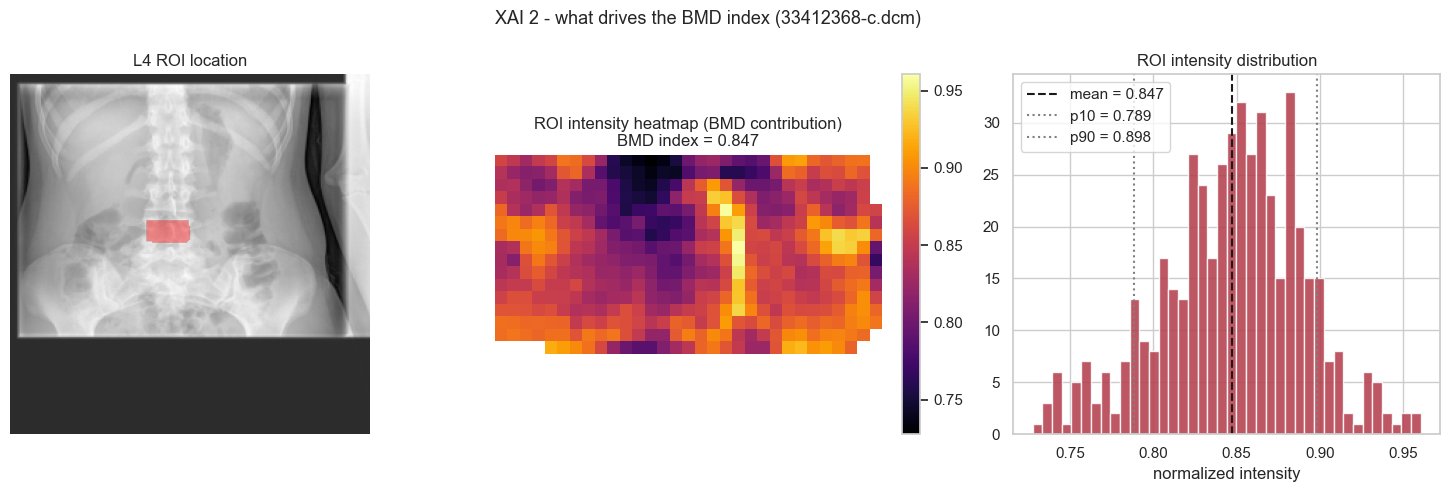

In [ ]:
# ============================================================================
#  XAI 2 - BMD-contribution heatmap (measurement explanation, model-agnostic)
# ============================================================================
p = (eval_items[:1] or buu_imgs[:1])[0]
rgb, gray_lin, H, W = load_xray(p)
m, status, inst, r = yolo_l4(rgb)
if m is not None and m.sum():
    roi = shrink_mask(m)
    ys, xs = np.where(roi > 0); y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
    patch = gray_lin[y0:y1 + 1, x0:x1 + 1].copy().astype(np.float32)
    patch[roi[y0:y1 + 1, x0:x1 + 1] == 0] = np.nan
    bmd = compute_bmd(gray_lin, roi)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(gray_lin, cmap="gray")
    ax[0].imshow(np.ma.masked_where(roi == 0, roi), cmap="autumn", alpha=0.4)
    ax[0].set_title("L4 ROI location"); ax[0].axis("off")

    im = ax[1].imshow(patch, cmap="inferno")
    ax[1].set_title(f"ROI intensity heatmap (BMD contribution)\nBMD index = {bmd['bmd_mean']:.3f}")
    ax[1].axis("off"); plt.colorbar(im, ax=ax[1], fraction=0.046)

    ax[2].hist(gray_lin[roi > 0].ravel(), bins=40, color="#B23A48", alpha=0.85)
    ax[2].axvline(bmd['bmd_mean'], color="k",    ls="--", label=f"mean = {bmd['bmd_mean']:.3f}")
    ax[2].axvline(bmd['bmd_p10'],  color="gray", ls=":",  label=f"p10 = {bmd['bmd_p10']:.3f}")
    ax[2].axvline(bmd['bmd_p90'],  color="gray", ls=":",  label=f"p90 = {bmd['bmd_p90']:.3f}")
    ax[2].set_title("ROI intensity distribution"); ax[2].set_xlabel("normalized intensity"); ax[2].legend()
    fig.suptitle(f"XAI 2 - what drives the BMD index ({os.path.basename(p)[-14:]})", fontsize=13)
    plt.tight_layout(); savefig(fig, "xai2_bmd_contribution.png"); plt.show()
else:
    print("No L4 detected on the sample; cannot draw the BMD-contribution heatmap.")

## Summary

- **Segmentation:** **YOLO26-seg** (`yolo26m-seg`) instance model with a class/4th-from-top L4 selector.
- **BMD:** linear normalized intensity inside the cancellous L4 ROI (relative proxy; calibrate with a
  phantom/DXA for absolute g/cm²).
- **Microarchitecture:** rotation-averaged GLCM (Contrast, Correlation, Energy/ASM, Homogeneity).
- **Evaluation:** dual-metric Dice (Deployed vs Matched) + confusion matrix + Bland-Altman on the
  DICOM test set; the Deployed-vs-Matched gap isolates the L4 indexing issue.
- **Web export:** `best.pt` → **ONNX** (`l4_v6_output/export/best.onnx`, opset 12, simplified) with a
  PyTorch-vs-ONNX parity check for the web project.
- **XAI:** gradient-based **Seg-Grad-CAM** on the L4 instance + a **BMD-contribution heatmap**.
- **Artifacts:** every cell saves its figure under `l4_v6_output/figures/`; per-image overlays/masks
  under `segmentation/`, metrics CSVs under `metrics/`, the ONNX model under `export/`.